# 02 - Stage 1: Anomaly Detection

Component C's target design is a **CNN-LSTM autoencoder** trained only on healthy pump
data. The reconstruction error becomes a rising "health score" as the pump drifts away
from normal behaviour.

This prototype swaps in a lightweight **bottlenecked MLP autoencoder over flattened
sliding windows** (`src/models/autoencoder.py`) so it trains in seconds with no GPU or
deep-learning framework - the windowing, training-on-healthy-data-only, and
reconstruction-error-as-health-score logic are otherwise identical to the target design.
Swapping in a real CNN-LSTM later means only touching that one file.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from src import config, data_loader, preprocessing, evaluate

from src.models.autoencoder import AnomalyAutoencoder

## Load data, split by time, scale, and build sliding windows
Window length: **{} hours** (Component B resamples everything onto an hourly index, so a 24-hour window covers a full daily cycle).

In [2]:
variant = 'variant3'
df = data_loader.load_variant(variant)
splits = data_loader.split_by_time(df)
feature_cols = config.FEATURE_COLS[variant]

scaler = preprocessing.fit_scaler(splits['train'], feature_cols)

X_train_win, X_train_last, meta_train = preprocessing.build_windows(splits['train'], feature_cols, scaler)
X_val_win, X_val_last, meta_val = preprocessing.build_windows(splits['val'], feature_cols, scaler)
X_test_win, X_test_last, meta_test = preprocessing.build_windows(splits['test'], feature_cols, scaler)

print('window shape (n_windows, window_size * n_features):', X_train_win.shape)
print('train windows:', len(meta_train), '| val windows:', len(meta_val), '| test windows:', len(meta_test))

window shape (n_windows, window_size * n_features): (4948, 552)
train windows: 4948 | val windows: 988 | test windows: 991


## Train the autoencoder on HEALTHY windows only

In [3]:
healthy_mask = (meta_train['failure_mode_label'] == 'Normal').values
print(f"Training on {healthy_mask.sum()} healthy windows out of {len(meta_train)} total train windows")

autoencoder = AnomalyAutoencoder(input_dim=X_train_win.shape[1])
autoencoder.fit(X_train_win[healthy_mask])
print('Alert-level thresholds (reconstruction error), calibrated on healthy training data:')
autoencoder.thresholds_

Training on 4648 healthy windows out of 4948 total train windows


Alert-level thresholds (reconstruction error), calibrated on healthy training data:


{'Normal': 0.09484052109952167,
 'Watch': 0.23994476049333716,
 'Warning': 0.28494893038528446,
 'Critical': 0.37571723034225507}

## Score every split and map to the four-level alert scale
(`Normal` / `Watch` / `Warning` / `Critical` — mirrors Component D's escalation)

In [4]:
health_test = autoencoder.reconstruction_error(X_test_win)
alert_test = autoencoder.alert_level(health_test)

meta_test = meta_test.copy()
meta_test['health_score'] = health_test
meta_test['alert_level'] = alert_test

pd.Series(alert_test).value_counts()

Critical    690
Normal      201
Watch        68
Warning      32
Name: count, dtype: int64

## How well does reconstruction error separate healthy from degrading behaviour?
Ground truth `anomaly_label` exists only because this is synthetic data - it is 1 once the hidden degradation level crosses a threshold. We use it here purely to sanity-check the autoencoder, not as a model input.

In [5]:
anomaly_true = meta_test['anomaly_label'].fillna(0).astype(int).values
anomaly_pred = (meta_test['alert_level'] != 'Normal').astype(int).values
m = evaluate.anomaly_detection_metrics(anomaly_true, anomaly_pred)
print(f"Precision: {m['precision']:.3f}   Recall: {m['recall']:.3f}   F1: {m['f1']:.3f}")

Precision: 0.873   Recall: 1.000   F1: 0.932


## Reconstruction-error trend for a failing pump
Re-scoring a pump's *entire* timeline (not just its test-split rows) makes the degradation trend visible end-to-end.

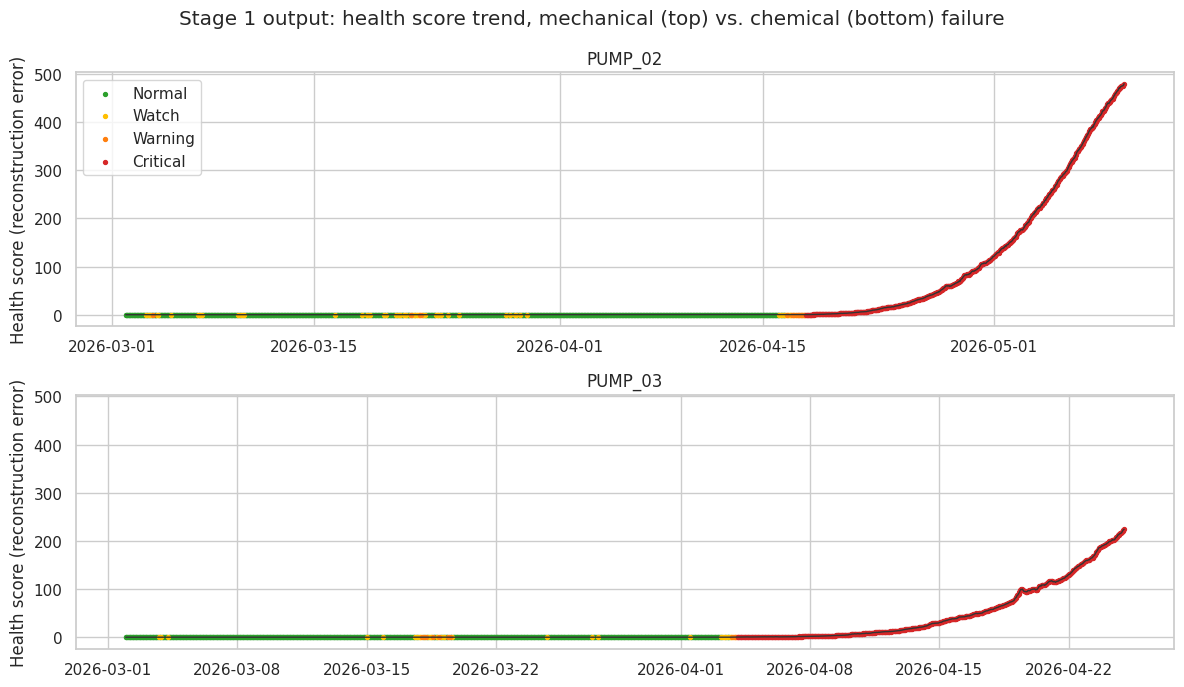

In [6]:
def score_full_pump(pump_id):
    pump_df = df[df.pump_id == pump_id]
    Xw, Xl, meta = preprocessing.build_windows(pump_df, feature_cols, scaler)
    h = autoencoder.reconstruction_error(Xw)
    meta = meta.copy()
    meta['health_score'] = h
    meta['alert_level'] = autoencoder.alert_level(h)
    return meta

colors = {'Normal': '#2ca02c', 'Watch': '#ffbf00', 'Warning': '#ff7f0e', 'Critical': '#d62728'}

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharey=True)
for ax, pump_id in zip(axes, ['PUMP_02', 'PUMP_03']):
    m = score_full_pump(pump_id)
    ax.plot(m['timestamp'], m['health_score'], color='#333333', linewidth=1)
    for level, color in colors.items():
        mask = m['alert_level'] == level
        ax.scatter(m.loc[mask, 'timestamp'], m.loc[mask, 'health_score'], s=8, color=color, label=level)
    ax.set_title(f'{pump_id}')
    ax.set_ylabel('Health score (reconstruction error)')
axes[0].legend(loc='upper left')
fig.suptitle('Stage 1 output: health score trend, mechanical (top) vs. chemical (bottom) failure')
fig.tight_layout()
plt.show()

**Takeaway:** the health score stays low and flat during normal operation and rises as each pump approaches its (synthetic) failure point, with the alert level escalating accordingly. This health-score trajectory is exactly what Stage 2 (RUL estimation) consumes next - see `03_stage2_rul_estimation.ipynb`.